# Overlapping Returns — how to 'discover' predictability that isn't there 🔗
### Why a long-horizon predictive regression can print a stunning t-stat from a driftless predictor, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_overlap_inflate_inference%3F: Confirmed](https://img.shields.io/badge/Does_overlap_inflate_inference%3F-Confirmed-8b949e?style=flat-square)

For decades the headline evidence that markets are predictable came from **long-horizon regressions**: take a valuation ratio (say the dividend yield) known *today*, and use it to forecast the **total return over the next 12 months** — then slide the window forward one month and do it again, and again. The R² climbs, the t-stats look huge, and it feels like a discovery.

There's a catch hiding in plain sight. Your 12-month return starting in January and your 12-month return starting in February **share eleven months** of the same data. Every neighbouring data point overlaps its neighbours almost completely — and that overlap quietly breaks the statistics.

So we run the experiment on a world we **built to have no predictability at all** — the predictor is pure noise, it forecasts *nothing* — and watch the naive regression 'discover' an edge anyway.

> 📓 **This is the plain-language layer.** Want the MA(h−1) residual structure, the Newey-West and Hodrick standard errors, and the Monte Carlo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic world. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from overlapping_returns import data, strategy as st

# The whole demo runs on the deterministic, offline seed-841 world. beta=0 => NO predictability,
# so any long-horizon t-stat / R² above the nominal 5% level is a pure overlap artefact.
DF, TRUTH = data.simulate_world(n_months=600, beta=0.0, rho=0.95, seed=841)
X, Rr = DF["x"].to_numpy(), DF["r"].to_numpy()
print("null world:", len(DF), "months,", DF.index[0].date(), "->", DF.index[-1].date(),
      "| beta %.0f (NO edge), rho %.2f (fp %s)" % (TRUTH.beta, TRUTH.rho, data.fingerprint(DF)))


null world: 600 months, 1970-01-31 -> 2019-12-31 | beta 0 (NO edge), rho 0.95 (fp 4111f0ae3f09)


## The answer first 🎯

| Question | Answer |
|---|---|
| Can *overlapping* long-horizon returns fake a great forecaster? | **Yes — hugely.** On a driftless predictor, the 12-month regression prints a naive **t = +4.84** and R² **3.9%** — a '5-sigma discovery' of an edge that *doesn't exist*. |
| How often does the naive 5% test cry wolf? | At 12 months, **56%** of the time (it should be 5%). At 24 months, **66%**. |
| Is there a fix? | **Yes.** The Hodrick (1992) standard error keeps the false-alarm rate at a correct **~6%** at every horizon. |
| Is any of the 'predictability' real? | **None of it.** The world has zero edge by construction — every bit is an artefact of the overlap. |

> The prettier the long-horizon R², the more suspicious you should be — overlap alone manufactures it for free.

## 1 · The claim

> *"Valuation ratios predict long-horizon returns — look at the R² and t-stats from regressing multi-year returns on the dividend yield."*

The recipe: line up each month's predictor against the **cumulative return over the following `h` months**, run one big regression, read off the t-stat. The problem is that consecutive `h`-month returns overlap by `h−1` months, so the regression's errors are **not independent** — and the ordinary formula for the t-stat assumes they are.

## 2 · So what?

Because a generation of 'the long run is predictable' conclusions rests on exactly this regression. If overlapping data can conjure a t-stat above 6 from a predictor with **zero** forecasting power, then those conclusions need re-examining with an honest standard error — which is precisely what Hodrick (1992) and the careful re-studies (Ang & Bekaert 2007; Boudoukh, Richardson & Whitelaw 2008) did, and much of the evidence softened.

## 3 · How would we even know?

We need a predictor we *know* forecasts nothing, so any 'predictability' must be fake. So we **build** a world: 600 months (50 years) of returns, plus a slow-moving, persistent predictor (like a valuation ratio) that is wired to have **zero** true forecasting power.

Then we run the long-horizon regression at several horizons and check the t-stat **two ways**:

1. the **naive** way everyone uses (the textbook OLS t-stat), and
2. an **honest** way (the Hodrick 1992 correction) that accounts for the fact that neighbouring long-horizon returns overlap.

If only the naive t-stat lights up, the 'discovery' is an overlap artefact.

## 4 · The teardown — let's actually run it

**One world, up close.** Same regression, three standard errors, as we lengthen the horizon. Watch the naive t-stat balloon while the honest (Hodrick) one stays calm — on a predictor that forecasts *nothing*.

    slope  naive_R2  t_naive   t_NW  t_Hodrick
h                                             
1   0.004     0.007    2.013  1.952      1.940
3   0.011     0.018    3.283  2.286      1.845
6   0.022     0.036    4.731  2.369      1.884
12  0.029     0.039    4.845  1.788      1.293
24  0.050     0.068    6.468  1.618      1.269


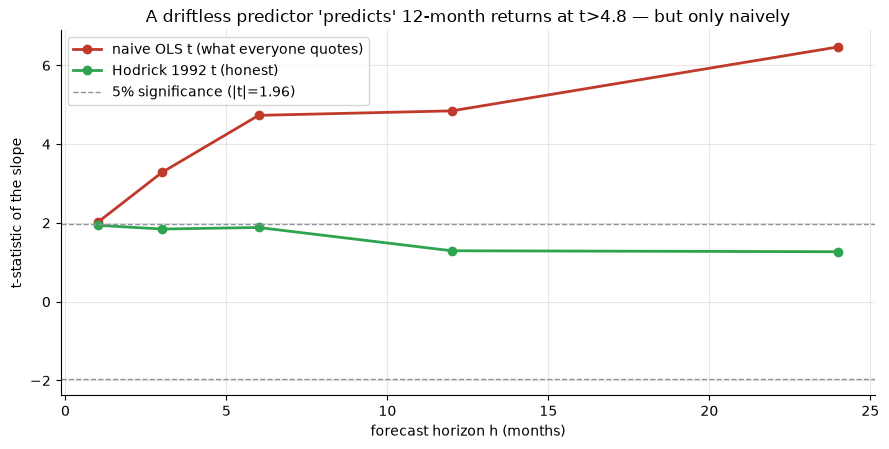

In [2]:
rows = []
for h in (1, 3, 6, 12, 24):
    o = st.predictive_regression(X, Rr, h)
    rows.append((h, o['slope'], o['r2'], o['t_naive'], o['t_nw'], o['t_hodrick']))
tab = pd.DataFrame(rows, columns=['h','slope','naive_R2','t_naive','t_NW','t_Hodrick']).set_index('h')
print(tab.round(3).to_string())
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(tab.index, tab['t_naive'], 'o-', c=RED, lw=2, label='naive OLS t (what everyone quotes)')
ax.plot(tab.index, tab['t_Hodrick'], 'o-', c=GREEN, lw=2, label='Hodrick 1992 t (honest)')
ax.axhline(1.96, ls='--', c=GREY, lw=1, label='5% significance (|t|=1.96)')
ax.axhline(-1.96, ls='--', c=GREY, lw=1)
ax.set_xlabel('forecast horizon h (months)'); ax.set_ylabel('t-statistic of the slope')
ax.set_title('A driftless predictor \'predicts\' 12-month returns at t>4.8 — but only naively')
ax.legend(); plt.tight_layout(); plt.show()

There it is. At a 12-month horizon the naive regression prints **t = +4.84** — it looks like an overwhelming discovery. But this world has **no predictability at all**: the honest Hodrick t-stat is **+1.29**, comfortably *inside* the ±1.96 band. The whole 'signal' is the overlap talking.

**Is this one world a fluke?** No. Repeat the experiment over many fresh worlds and count how often each test wrongly declares 'significant'. An honest 5% test should cry wolf 5% of the time. Here's a quick live Monte Carlo at the 12-month horizon:

12-month horizon, 200 fresh NULL worlds — false-alarm rate of a 5% test:
  naive OLS :  53.5%   (should be 5%)
  Hodrick   :   6.0%   (should be 5%)


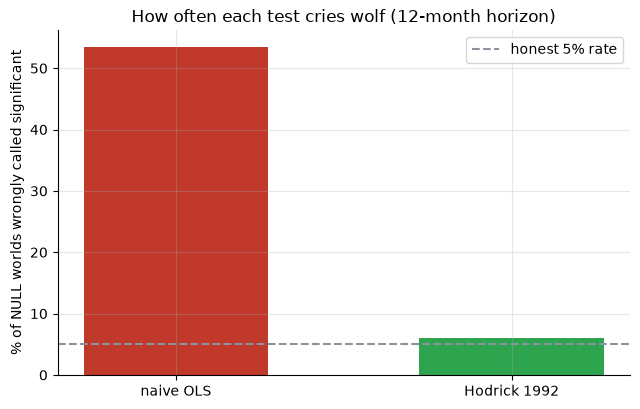

In [3]:
e = st.size_experiment(data, h=12, beta=0.0, rho=0.95, n_sims=200, base_seed=841)
print(f"12-month horizon, {e['n_sims']} fresh NULL worlds — false-alarm rate of a 5% test:")
print(f"  naive OLS : {e['reject_naive']*100:5.1f}%   (should be 5%)")
print(f"  Hodrick   : {e['reject_hodrick']*100:5.1f}%   (should be 5%)")
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(['naive OLS','Hodrick 1992'], [e['reject_naive']*100, e['reject_hodrick']*100],
       color=[RED, GREEN], width=.55)
ax.axhline(5, ls='--', c=GREY, lw=1.5, label='honest 5% rate')
ax.set_ylabel('% of NULL worlds wrongly called significant')
ax.set_title('How often each test cries wolf (12-month horizon)')
ax.legend(); plt.tight_layout(); plt.show()

The naive test flags a phantom edge in **more than half** of no-edge worlds; the Hodrick test stays near the honest 5%. And it gets *worse* the longer the horizon — over the full 2,000-world run the naive false-alarm rate climbs from **6% at 1 month** to **66% at 24 months**:

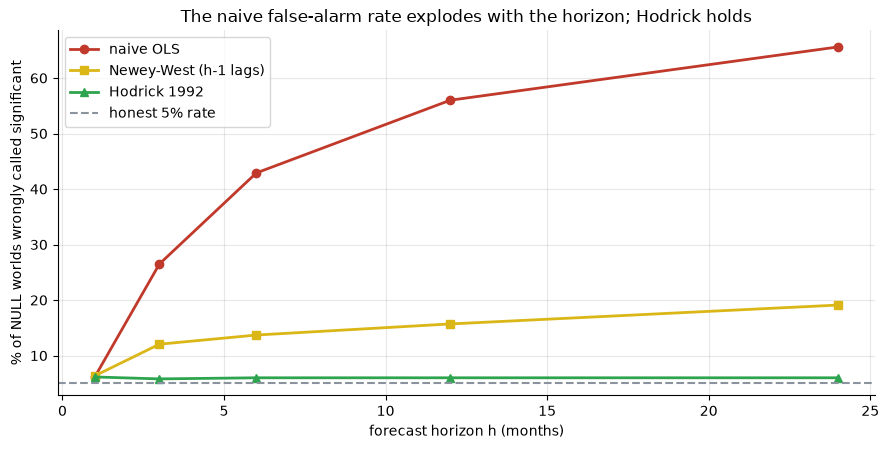

frozen 2,000-sim run (docs/results.md):
  h= 1: naive  6.2%  NW  6.3%  Hodrick  6.2%
  h= 3: naive 26.5%  NW 12.0%  Hodrick  5.8%
  h= 6: naive 42.9%  NW 13.7%  Hodrick  6.0%
  h=12: naive 56.0%  NW 15.7%  Hodrick  6.0%
  h=24: naive 65.6%  NW 19.1%  Hodrick  6.0%


In [4]:
null = [(1, 0.0615, 0.0635, 0.0615), (3, 0.265, 0.1205, 0.058), (6, 0.429, 0.137, 0.06), (12, 0.56, 0.157, 0.06), (24, 0.656, 0.191, 0.06)]
hh = [r[0] for r in null]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(hh, [r[1]*100 for r in null], 'o-', c=RED, lw=2, label='naive OLS')
ax.plot(hh, [r[2]*100 for r in null], 's-', c=AMBER, lw=2, label='Newey-West (h-1 lags)')
ax.plot(hh, [r[3]*100 for r in null], '^-', c=GREEN, lw=2, label='Hodrick 1992')
ax.axhline(5, ls='--', c=GREY, lw=1.5, label='honest 5% rate')
ax.set_xlabel('forecast horizon h (months)')
ax.set_ylabel('% of NULL worlds wrongly called significant')
ax.set_title('The naive false-alarm rate explodes with the horizon; Hodrick holds')
ax.legend(); plt.tight_layout(); plt.show()
print('frozen 2,000-sim run (docs/results.md):')
for h, rn, rw, rh in null:
    print(f'  h={h:2d}: naive {rn*100:4.1f}%  NW {rw*100:4.1f}%  Hodrick {rh*100:4.1f}%')

## 5 · The verdict

- **Signal — None.** The world has zero predictability by construction; the long-horizon 'edge' is entirely an overlap artefact. Nothing real to detect.
- **Tradability — Mirage.** You can't trade an inflated t-stat — the apparent forecast has no out-of-sample value and evaporates under an honest standard error.
- **Does overlap inflate inference? — Confirmed.** The naive false-alarm rate hits 66% at 24 months; the Hodrick correction restores an honest ~6%.

## 6 · Could you actually trade it?

No — there is nothing to trade. The regression describes a relationship that **does not exist**; its out-of-sample forecast is worthless. The only thing the overlap inflated was your *confidence*, not your returns. The fix isn't a better strategy, it's a correct standard error.

## 7 · Going further 🚪

- **The fix is public and old.** The Hodrick (1992) standard error and Newey-West (1987) HAC both defang the overlap — see the quants notebook for exactly how.
- **The cousins on this desk.** [838 HAC-Necessity](../../838-hac-necessity/) is the same autocorrelation problem for a *strategy's own daily P&L*; [835 Spurious-Regression](../../835-spurious-regression/) fakes a relationship from *trending* series; [346 Multiple-Testing](../../346-multiple-testing/) fakes significance from *many hypotheses*.

*Think a long-horizon R² proves the long run is predictable? Fork this, feed in a real dividend-yield series, and watch the Hodrick correction cut the t-stat down to size.*